Simulação da Rede

In [33]:
import py_dss_interface
from py_dss_toolkit import dss_tools
import pandas as pd
import pickle

dss = py_dss_interface.DSS()

dss_file = r"C:\Dados_teste\OpenDSS\CBA\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"
#dss_file = r"C:\Users\IVAN SANTOS\Documents\OpenDSS\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"

dss_tools.update_dss(dss)

dss.text(f"compile [{dss_file}]")

cases = ["base", "60_gd", "60_gd_30_bess", "120_gd", "120_gd_60_bess"]
titles = {
    "base": "Caso Base",
    "60_gd": "Caso com 60 GDs",
    "60_gd_30_bess": "Caso com 60 GDs e 30 Baterias",
    "120_gd": "Caso com 120 GDs",
    "120_gd_60_bess": "Caso com 120 GDs e 60 Baterias",
}


dfs_monitor = {}
df_energymeter = pd.DataFrame(columns=["Caso", "Perdas (kWh)", "Energia (kWh)", "Energia injetada (kWh)"])
dfs_voltage = {}
dfs_monitor_pf = {}
dfs_storage = {}
dfs_monitor_pv = {}

for case in cases:

    dss.text(f"compile [{dss_file}]")

    if case == "60_gd":
        dss.text("Redirect 'PV_System_60_MeiaPonte.dss'")
        dss.text("Redirect 'Monitor_PV.dss'")
    
    elif case == "120_gd":
        dss.text("Redirect 'PV_System_120_MeiaPonte.dss'")
        dss.text("Redirect 'Monitores_PV_120.dss'")
    
    elif case == "60_gd_30_bess":
        dss.text("Redirect 'PV_System_60_MeiaPonte.dss'")
        #dss.text("Redirect 'BATERIAS_30.dss'")
        dss.text("Redirect 'Battery_30.dss'")

    elif case == "120_gd_60_bess":
        dss.text("Redirect 'PV_System_120_MeiaPonte.dss'")
        #dss.text("Redirect 'BATERIAS_60.dss'")
        dss.text("Redirect 'Battery_60.dss'")

    else:
        dss.text("!Redirect 'BATERIAS_60.dss'")
    
    dss.text(f"buscoords BusCoords.csv")

    dss.text("set mode=daily")
    dss.text("set stepsize=1h")
    dss.text("set number=1")

    socs = []

    for h in range(48):
        if dss.solution.hour == 24:
            dss.meters.reset_all()
        dss.solution.solve()

        if dss.storages.count > 0:
            dss.storages.first()
            dss.storages.next()   #Para pegar a bateria 2, comentar se for pegar a 1
            name_battery = dss.storages.name
            soc = dss.storages.pu_soc
            socs.append(soc)

    #dss.text("sample")

    if dss.storages.count > 0:
        dfs_storage[f"{name_battery}_{case}"] = socs

    meter_values = dss.meters.register_values

    #print(f"\n {titles[case]}\n")
    #print(f"Energia total: {meter_values[0]:.2f} kWh")
    #print(f"Perdas totais: {meter_values[12]:.2f} kWh\n")

    ##### Monitor - Power Flow Substation ####

    dfs_monitor[f"{case}_df"] = dss_tools.results.monitor("feeder")
    dfs_monitor[f"{case}_df"]["Total Power"] = dfs_monitor[f"{case}_df"][' P1 (kW)'] + dfs_monitor[f"{case}_df"][' P2 (kW)'] + dfs_monitor[f"{case}_df"][' P3 (kW)']

    ##### Monitors - Voltage #####

    monitor_names = dss.monitors.names

    for monitor_name in monitor_names:
        if "voltage" in monitor_name.lower():
            dfs_voltage[f"{monitor_name}_{case}_df"] = dss_tools.results.monitor(monitor_name)
        
        ##### Monitors - Power Flow #####

        else:
            dfs_monitor_pf[f"{monitor_name}_{case}_df"] = dss_tools.results.monitor(monitor_name)

    
    injection = 0
    for chave, df in dfs_monitor_pf.items():    #Items() retorna a tupla (chave, item)

        if chave.endswith(f"_{case}_df") and "trf_" in chave:
            if " P3 (kW)" in df.columns:
                df["Total Power"] = df[" P1 (kW)"] + df[" P2 (kW)"] + df[" P3 (kW)"]
            else:
                df["Total Power"] = df[" P1 (kW)"] + df[" P2 (kW)"]

            injection += df.query("`Total Power` < 0 and Hour > 24")["Total Power"].sum()


    ### Monitors - Geração PV

    for chave in dfs_monitor_pf:
        if chave.endswith(f"_{case}_df") and "pv_" in chave:
            dfs_monitor_pv[chave] = dfs_monitor_pf[chave]

    with open("dataframes.pkl", "wb") as f:
        pickle.dump(dfs_monitor_pv, f)

    ######## Criação do DataFrame "Energymeter" #####
    nova_linha = pd.DataFrame([{
        "Caso": titles[case], 
        "Energia (kWh)": meter_values[0], 
        "Perdas (kWh)": meter_values[12],
        "Energia injetada (kWh)": injection
    }])

    df_energymeter = pd.concat([df_energymeter, nova_linha], ignore_index=True)

#display(dfs_monitor["120_gd_60_bess_df"])

storages_soc_df = pd.DataFrame(dfs_storage)
#display(storages_soc_df)

display(df_energymeter)
print(dfs_voltage["voltage_trf_5286812a_120_gd_60_bess_df"].columns)


,Caso,Perdas (kWh),Energia (kWh),Energia injetada (kWh)
0,Caso Base,6277.879191,124421.278044,0.0
1,Caso com 60 GDs,5348.555803,78896.6063,-26567.828373
2,Caso com 60 GDs e 30 Baterias,4157.969591,79737.997144,-12837.63195
3,Caso com 120 GDs,5882.469108,49444.513986,-43688.849394
4,Caso com 120 GDs e 60 Baterias,3397.70802,50265.237221,-19613.652733


Index(['Hour', 'sec', ' V1', ' VAngle1', ' V2', ' VAngle2', ' V3', ' VAngle3',
       ' V4', ' VAngle4', ' I1', ' IAngle1', ' I2', ' IAngle2', ' I3',
       ' IAngle3', ' I4', ' IAngle4'],
      dtype='str')


In [13]:
del list
with open("Dataframes.txt", "w", encoding="utf-8") as f:
    nomes = list(dfs_monitor_pf.keys())

    for nome in nomes:
        f.write(nome + "\n")

Gráficos de Potência e Tensão

,Caso,Perdas (kWh),Energia (kWh),Energia injetada (kWh)
0,Caso Base,6277.879191,124421.278044,0.0
1,Caso com 60 GDs,5348.555803,78896.6063,-26567.828373
2,Caso com 60 GDs e 30 Baterias,4157.969591,79737.997144,-12837.63195
3,Caso com 120 GDs,5882.469108,49444.513986,-43688.849394
4,Caso com 120 GDs e 60 Baterias,3397.70802,50265.237221,-19613.652733


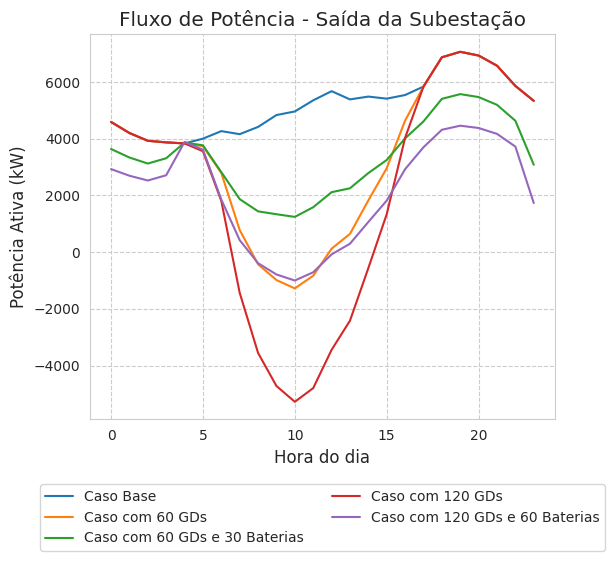

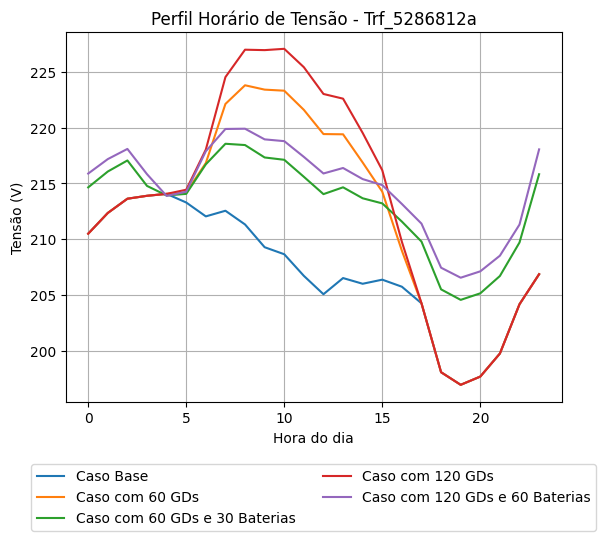

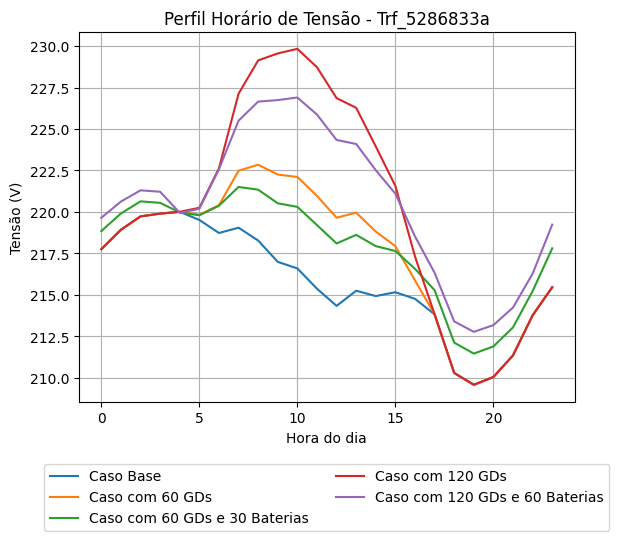

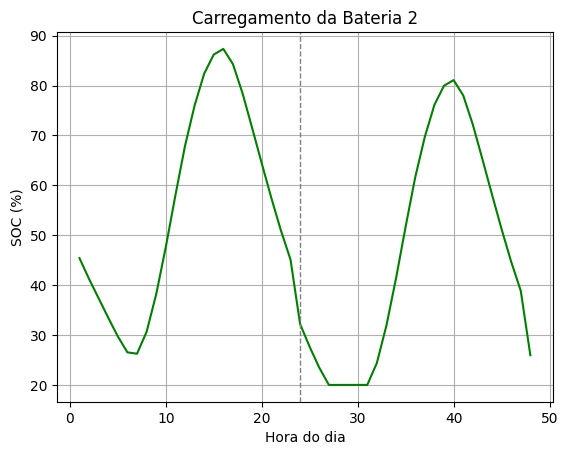

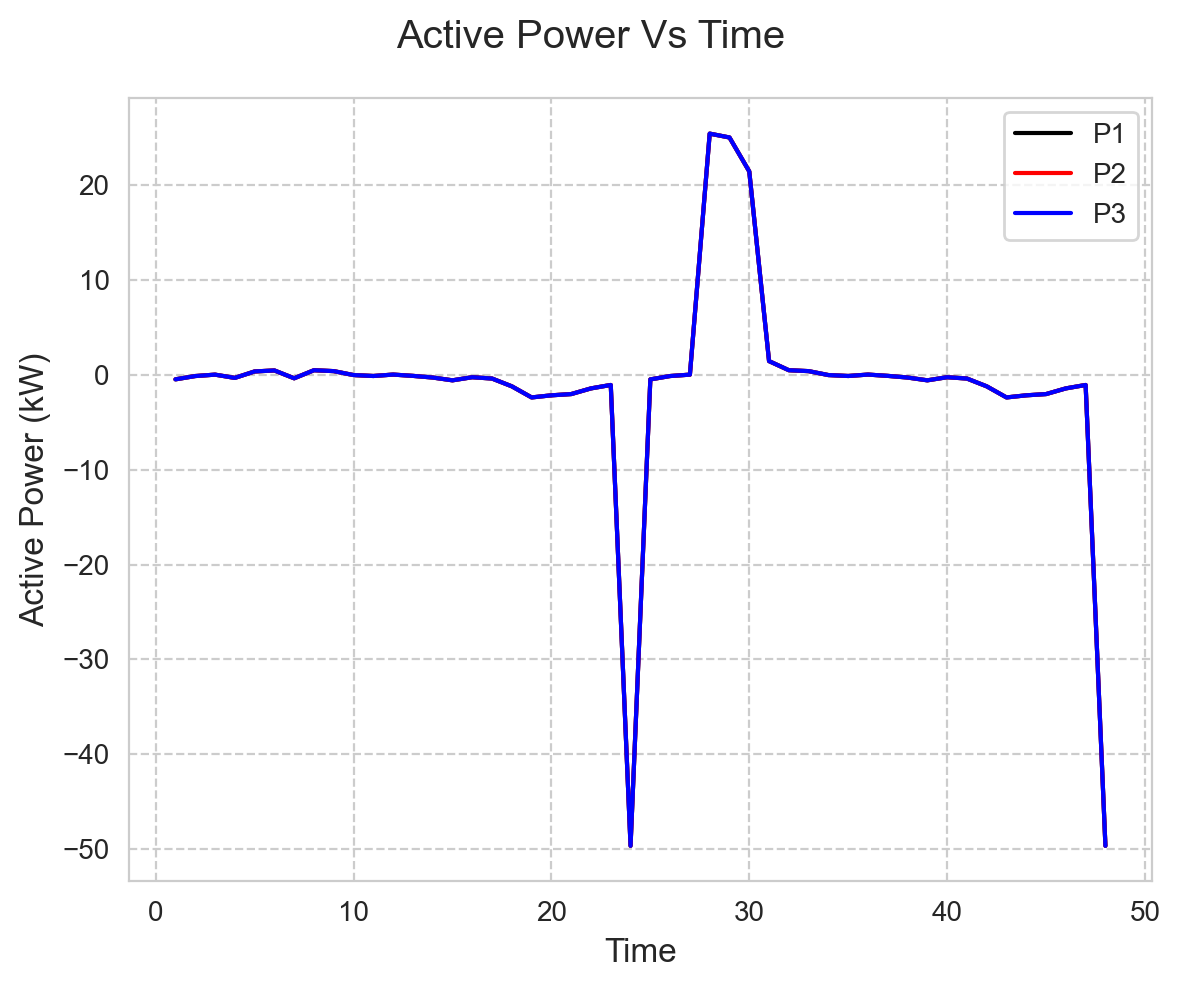

(<Figure size 1200x1000 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='Active Power (kW)'>)

In [34]:
###### Resultados #####
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

display(df_energymeter)

titles = {
    "base": "Caso Base",
    "60_gd": "Caso com 60 GDs",
    "60_gd_30_bess": "Caso com 60 GDs e 30 Baterias",
    "120_gd": "Caso com 120 GDs",
    "120_gd_60_bess": "Caso com 120 GDs e 60 Baterias",
}
####### Gráfico Subestação Fluxo de Potência ####

x = np.linspace(0, 23, 24)
for case in cases:
    dfs_monitor[f"{case}_df"] = dfs_monitor[f"{case}_df"].query("Hour > 24")
    plt.plot(
        x, 
        dfs_monitor[f"{case}_df"]["Total Power"], label=titles[case])
    

plt.title("Fluxo de Potência - Saída da Subestação")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa (kW)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
plt.style.use("default")
plt.show()

####### Gráfico Tensão Trf 5286812a ######
for case in cases:
    df1 = dfs_voltage[f"voltage_trf_5286812a_{case}_df"]
    df1 = dfs_voltage[f"voltage_trf_5286812a_{case}_df"].query("Hour > 24")
    plt.plot(
        x, 
        df1[" V1"], label=titles[case])
    
plt.title("Perfil Horário de Tensão - Trf_5286812a")
plt.xlabel("Hora do dia")
plt.ylabel("Tensão (V)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
plt.show()

###### Gráfico Tensão Trf_5286833a #####

for case in cases:
    df2= dfs_voltage[f"voltage_trf_5286833a_{case}_df"]
    df2= dfs_voltage[f"voltage_trf_5286833a_{case}_df"].query("Hour > 24")
    plt.plot(
        x, 
        df2[" V1"], label=titles[case])
    
plt.title("Perfil Horário de Tensão - Trf_5286833a")
plt.xlabel("Hora do dia")
plt.ylabel("Tensão (V)")
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.grid(True)
#plt.style.use("dark_background")
plt.show()

##### Gráfico de carregamento ####

x_48 = np.linspace(1,48,48)
#x_48 = x

plt.plot(x_48, storages_soc_df["battery_2_60_gd_30_bess"]*100, color="green")
plt.axvline(x=24, color='gray', linestyle='--', linewidth=1)
#plt.axvline(x=48, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Hora do dia")
plt.ylabel("SOC (%)")
plt.title("Carregamento da Bateria 2")
plt.grid(True)
plt.show()

df_plotly = pd.DataFrame()
df_plotly["Hora"] = x_48
df_plotly["SOC (%)"] = storages_soc_df["battery_2_60_gd_30_bess"]*100
fig = px.line(df_plotly, x="Hora", y="SOC (%)", template="plotly_dark")
fig.show()

dss_tools.static_view.p_vs_time("trf_5286964a")


Mapas

In [16]:
#Rodar apenas quando for criar os mapas
dss.text("set mode=daily")
dss.text("set stepsize=1h")
dss.text("set number=1")

for _ in range(36):   # chega até a hora 35 (hora com maiores valores de tensão)
    dss.solution.solve()

#Rodar o código principal novamente para ter todos os dados

Version 11.0.0.1 (64-bit build) - Charlottesville; License Status: Open 


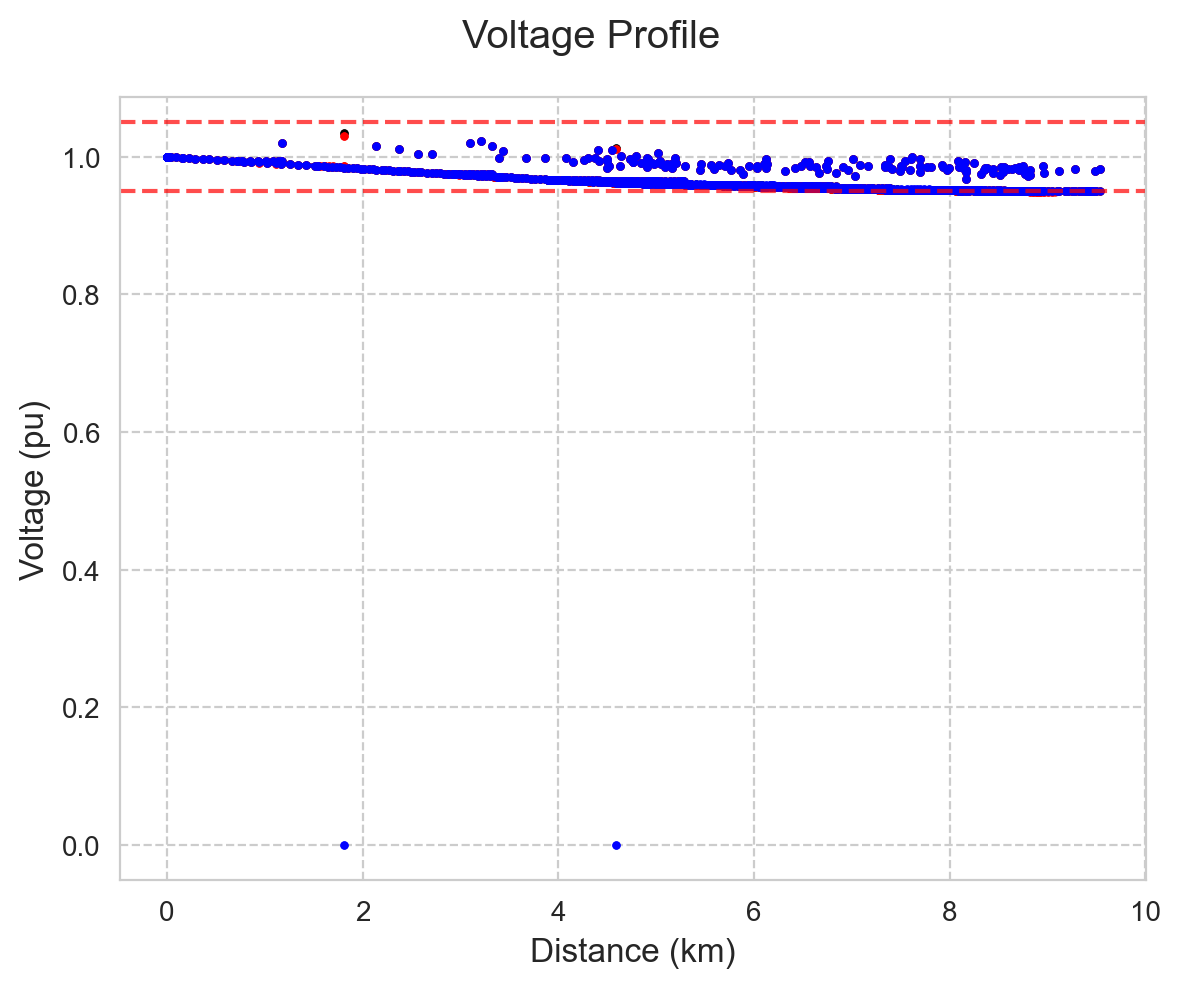

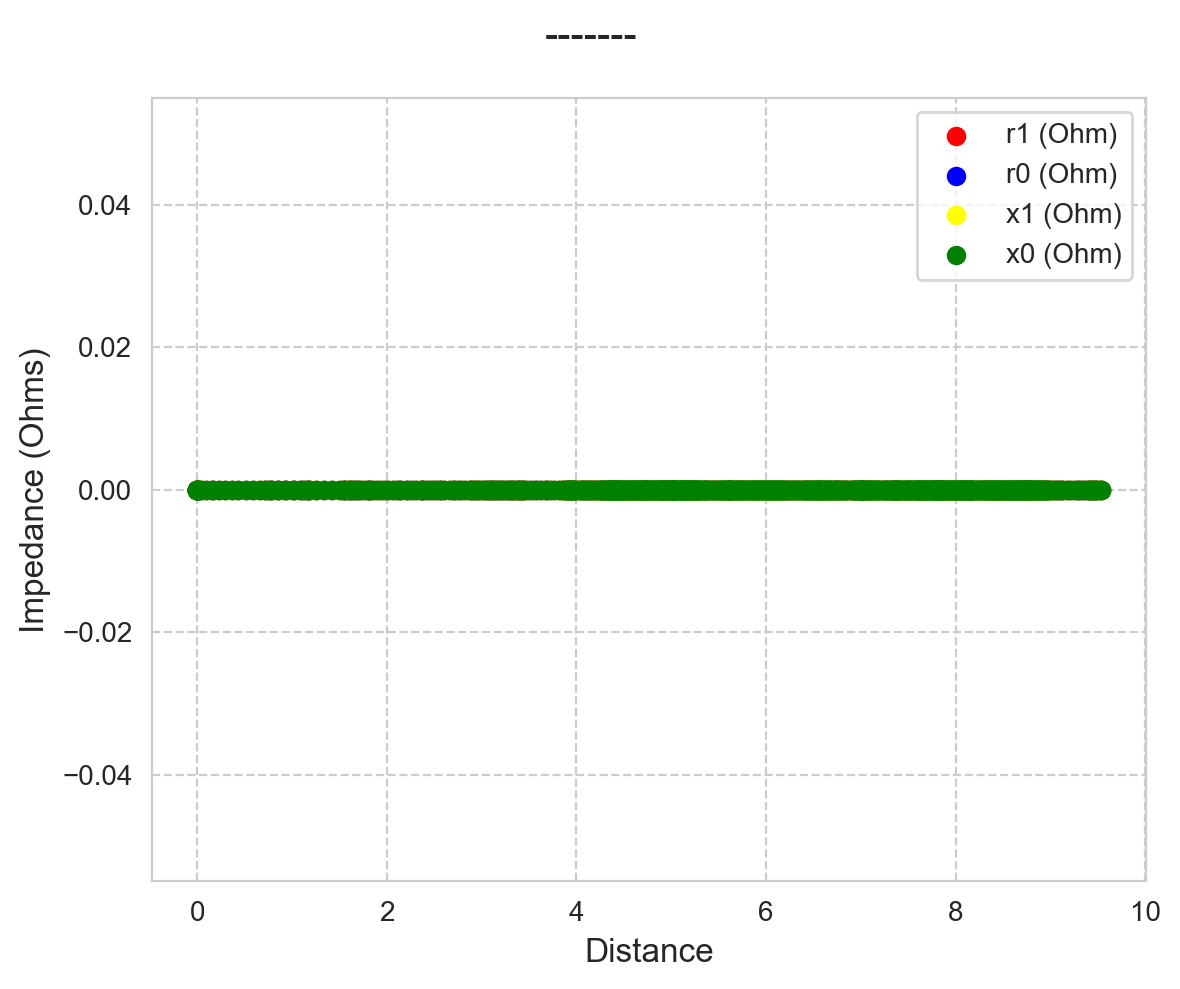

In [ ]:
#Rodar 

print(dss.dssinterface.version)
dss_tools.update_dss(dss)
########## Mapas ############

dss_tools.interactive_view.circuit_plot(parameter="voltage", show=True)
dss_tools.interactive_view.circuit_geoplot(parameter="voltage", show=True)
#dss_tools.interactive_view.voltage_profile(show=True)
dss_tools.static_view.voltage_profile(show=True, legend=False)
dss_tools.static_view.impedances_vs_distance(show=True)


Análise das Tensões

In [43]:
import re

monitor_names = dss.monitors.names
cases = ["base", "60_gd", "60_gd_30_bess", "120_gd", "120_gd_60_bess"]
voltages = ["V1", "V2", "V3"]

for monitor in monitor_names:
    if "voltage" not in monitor.lower():
        continue
    
    base = dfs_voltage[f"{monitor}_base_df"]

    for case in cases:
        df = dfs_voltage[f"{monitor}_{case}_df"]

        for v in voltages:

            if case == "base":
                df[f"diff_percent_{v}"] = 0.0
                continue
            
            if f" {v}" not in df.columns:
                continue

            df[f"diff_percent_{v}"] = 100*(df[f" {v}"] - base[f" {v}"])/base[f" {v}"]

estatisticas = []

for nome, df in dfs_voltage.items():

    linha = {"Monitor": nome}
    
    df = df.query("Hour > 24")

    if df.empty:
        continue

    for v in voltages:

        if f" {v}" not in df.columns:
            continue

        if "voltage_feeder" in nome:
            match = re.search(r"voltage_feeder_(.*?)_df$", nome)
        else:
            match = re.search(r"voltage_trf_.*?_(.*?)_df$", nome)
          
        linha["Caso"] = titles[match.group(1)]
        linha[f"{v}_max"] = df[f" {v}"].max()
        linha[f"{v}_hora_max"] = df.loc[df[f" {v}"].idxmax(), "Hour"]
        linha[f"{v}_min"] = df[f" {v}"].min()
        linha[f"{v}_hora_min"] = df.loc[df[f" {v}"].idxmin(), "Hour"]
        linha[f"{v}_medio"] = df[f" {v}"].mean()

        if f"diff_percent_{v}" in df.columns:
            linha[f"diff_{v}_max"] = df[f"diff_percent_{v}"].max()
            linha[f"diff_{v}_hora_max"] = df.loc[df[f"diff_percent_{v}"].idxmax(), "Hour"]
            linha[f"diff_{v}_min"] = df[f"diff_percent_{v}"].min()
            linha[f"diff_{v}_hora_min"] = df.loc[df[f"diff_percent_{v}"].idxmin(), "Hour"]

    estatisticas.append(linha)

df_stats = pd.DataFrame(estatisticas)

#### Query Caso ###

df_stats = df_stats.query("Caso == 'Caso com 120 GDs'")

#Restrições estatísticas
df_stats_bt = df_stats.query("V1_max < 1000")
df_stats_bt = df_stats.query("V2_max < 1000")

df_stats = df_stats.query("V2_min > 1")


#Níveis Mínimos
print("\n Níveis mínimos de tensão V1\n")
df_stats = df_stats.sort_values(by='V1_min', ascending=True)
display(df_stats[["Monitor", "Caso", "V1_min", "V1_hora_min"]].head(5))

print("\n Níveis mínimos de tensão V2\n")
df_stats = df_stats.sort_values(by='V2_min', ascending=True)
display(df_stats[["Monitor", "Caso", "V2_min", "V2_hora_min"]].head(5))

print("\n Níveis mínimos de tensão V3\n")
df_stats = df_stats.sort_values(by='V3_min', ascending=True)
display(df_stats[["Monitor", "Caso", "V3_min", "V3_hora_min"]].head(5))

#Níveis Máximos

print("\n Maiores valores de tensão V1\n")
df_stats_bt = df_stats_bt.sort_values(by='V1_max', ascending=False)
display(df_stats_bt[["Monitor", "Caso", "V1_max", "V1_hora_max"]].head(5))

print("\n Maiores valores de tensão V2\n")
display(df_stats_bt[["Monitor", "Caso", "V2_max", "V2_hora_max"]].sort_values(by='V2_max', ascending=False).head(5))

print("\n Maiores valores de tensão V3\n")
df_stats_bt = df_stats_bt.sort_values(by='V3_max', ascending=False)
display(df_stats_bt[["Monitor", "Caso", "V3_max", "V3_hora_max"]].head(5))

#Elevação Percentual

print("\n Maiores elevações percentuais V1\n")
df_stats = df_stats.sort_values(by='diff_V1_max', ascending=False)
display(df_stats[["Monitor", "Caso", "diff_V1_max", "diff_V1_hora_max"]].head(5))

print("\n Maiores elevações percentuais V2\n")
df_stats = df_stats.sort_values(by='diff_V2_max', ascending=False)
display(df_stats[["Monitor", "Caso", "diff_V2_max", "diff_V2_hora_max"]].head(5))


print("\n Maiores elevações percentuais V3\n")
df_stats = df_stats.sort_values(by='diff_V3_max', ascending=False)
display(df_stats[["Monitor", "Caso", "diff_V3_max", "diff_V3_hora_max"]].head(5))

#Valores Médios
df_stats = df_stats.query("V1_medio < 1000")
media_global_v1 = df_stats["V1_medio"].mean()
media_global_v2 = df_stats["V2_medio"].mean()
media_global_v3 = df_stats["V3_medio"].mean()

print(f"\n Nível médio de tensão V1: {media_global_v1}\n")


print(f"\n Nível médio de tensão V2: {media_global_v2}\n")


print(f"\n Nível médio de tensão V3: {media_global_v3}\n")


#display(dfs_voltage["voltage_trf_5286812a_120_gd_60_bess_df"])
#print(dfs_voltage["voltage_trf_5286812a_120_gd_60_bess_df"].columns)


 Níveis mínimos de tensão V1



,Monitor,Caso,V1_min,V1_hora_min
462,voltage_trf_5286812a_120_gd_df,Caso com 120 GDs,196.943939,44.0
560,voltage_trf_5286964a_120_gd_df,Caso com 120 GDs,198.560272,44.0
471,voltage_trf_5286821a_120_gd_df,Caso com 120 GDs,199.689880,44.0
460,voltage_trf_5286810a_120_gd_df,Caso com 120 GDs,200.046127,44.0
514,voltage_trf_5286933a_120_gd_df,Caso com 120 GDs,200.093903,44.0



 Níveis mínimos de tensão V2



,Monitor,Caso,V2_min,V2_hora_min
462,voltage_trf_5286812a_120_gd_df,Caso com 120 GDs,196.942657,44.0
560,voltage_trf_5286964a_120_gd_df,Caso com 120 GDs,198.558929,44.0
471,voltage_trf_5286821a_120_gd_df,Caso com 120 GDs,199.688583,44.0
460,voltage_trf_5286810a_120_gd_df,Caso com 120 GDs,200.044800,44.0
514,voltage_trf_5286933a_120_gd_df,Caso com 120 GDs,200.092606,44.0



 Níveis mínimos de tensão V3



...


 Maiores elevações percentuais V2



,Monitor,Caso,diff_V2_max,diff_V2_hora_max
462,voltage_trf_5286812a_120_gd_df,Caso com 120 GDs,9.047740,36.0
460,voltage_trf_5286810a_120_gd_df,Caso com 120 GDs,8.478391,36.0
465,voltage_trf_5286815a_120_gd_df,Caso com 120 GDs,8.436750,36.0
471,voltage_trf_5286821a_120_gd_df,Caso com 120 GDs,8.325295,36.0
514,voltage_trf_5286933a_120_gd_df,Caso com 120 GDs,8.323680,36.0



 Maiores elevações percentuais V3



,Monitor,Caso,diff_V3_max,diff_V3_hora_max
462,voltage_trf_5286812a_120_gd_df,Caso com 120 GDs,9.047926,36.0
460,voltage_trf_5286810a_120_gd_df,Caso com 120 GDs,8.478569,36.0
465,voltage_trf_5286815a_120_gd_df,Caso com 120 GDs,8.436928,36.0
471,voltage_trf_5286821a_120_gd_df,Caso com 120 GDs,8.325464,36.0
514,voltage_trf_5286933a_120_gd_df,Caso com 120 GDs,8.323858,36.0



 Nível médio de tensão V1: 218.2964489623446


 Nível médio de tensão V2: 218.29550606477346


 Nível médio de tensão V3: 218.2934399282397



Testes Aleatórios

In [30]:
dss.circuit.set_active_element("Storage.Battery_2")
eff_charge = dss.text("? Storage.Battery_1.%EffCharge")
eff_discharge = dss.text("? Storage.Battery_1.%EffCharge")

print("Eficiência Carga: ", eff_charge)
print("Eficiência Descarga: ", eff_discharge)

Eficiência Carga:  90
Eficiência Descarga:  90


In [35]:
dfs_voltage["voltage_trf_5286708a_120_gd_60_bess_df"].columns
#display(dfs_voltage["voltage_trf_5286708a_120_gd_60_bess_df"][["Hour", " V1", " V2", " V3"]])

Index(['Hour', 'sec', ' V1', ' VAngle1', ' V2', ' VAngle2', ' I1', ' IAngle1',
       ' I2', ' IAngle2', 'diff_percent_V1', 'diff_percent_V2'],
      dtype='str')

In [30]:
#Linhas

line_df = dss_tools.model.lines_df
line_df['name'] = 'line.' + line_df['name']
num_phases = line_df.set_index("name")["phases"]
dss_tools.interactive_view.user_categorical_defined_settings.results = num_phases
dss_tools.interactive_view.user_categorical_defined_settings.color_map = {'3': ["3-phases", "blue"],
        '2': ["2-phases", "red"],
        '1': ["1-phase", "green"]}
dss_tools.interactive_view.circuit_plot(parameter="user categorical defined", title="My Phases")

#Gráfico interativo transformadores

dss_tools.interactive_view.vmag_vs_time("voltage_trf_5286833a", show=True)
dss_tools.interactive_view.p_vs_time("feeder", show=True)



In [ ]:
display(dfs_monitor_pf["trf_5286812a_120_gd_60_bess_df"][["Hour", "Total Power"]])

,Hour,Total Power
0,1.0,-1.524521
1,2.0,-0.551773
2,3.0,-0.122530
3,4.0,-1.041169
4,5.0,0.793122
5,6.0,1.076896
6,7.0,-0.851440
7,8.0,-0.179327
8,9.0,-0.364425
9,10.0,1.468350


In [21]:
dss_tools.interactive_view.circuit_geoplot(parameter="phases", show=True, title="Alimentador 5 da Subestação Meia Ponte")
#dss_tools.interactive_view.user_numerical_defined_settings.

df_energymeter.to_csv("Dados energia CBA.csv")

